# Monocular depth estimation

> Добавить блок с цитатой



**Author:** [Victor Basu](https://www.linkedin.com/in/victor-basu-520958147)<br>
**Date created:** 2021/08/30<br>
**Last modified:** 2024/08/13<br>
**Description:** Implement a depth estimation model with a convnet.

## Введение

_Оценка глубины_ — это важный шаг на пути к определению геометрии сцены по 2D-изображениям.
Цель _монокулярной оценки глубины_ — предсказать значение глубины для каждого пикселя или
определить информацию о глубине, используя в качестве входных данных только одно RGB-изображение.
В этом примере будет показан подход к созданию модели оценки глубины с помощью свёрточной нейронной сети
и простых функций потерь.

![Оценка глубины](https://paperswithcode.com/media/thumbnails/task/task-0000000605-d9849a91.jpg)

## Setup

In [9]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import sys

import tensorflow as tf
from tensorflow import keras as keras

from tensorflow.keras import layers
from tensorflow.keras import ops
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

keras.utils.set_random_seed(123)

#### Описание библиотек

- **os** - это стандартная библиотека Python, которая предоставляет функции для взаимодействия с операционной системой. Она позволяет выполнять операции, такие как работа с файловой системой, управление окружением и выполнение системных команд.

- **sys** - это стандартная библиотека Python, которая предоставляет доступ к некоторым переменным и функциям, связанным с интерпретатором Python. Она позволяет управлять аргументами командной строки, выходом и другими аспектами работы интерпретатора.

- **tensorflow** - это мощная библиотека для машинного обучения и глубокого обучения, разработанная Google. Она предоставляет инструменты для создания и обучения нейронных сетей, а также для выполнения вычислений на графических процессорах (GPU).

- **keras** - это высокоуровневая библиотека для создания и обучения нейронных сетей, которая работает поверх TensorFlow. Она упрощает процесс построения моделей глубокого обучения, предоставляя удобный интерфейс для работы с различными типами слоев и оптимизаторов.

- **layers** - это модуль в Keras, который содержит различные типы слоев, используемых для построения нейронных сетей, такие как полносвязные слои, сверточные слои и рекуррентные слои.

- **ops** - это модуль в Keras, который предоставляет операции, используемые в процессе построения и обучения моделей. Он включает в себя функции для работы с тензорами и выполнения различных математических операций.

- **pandas** - это библиотека для анализа данных, которая предоставляет структуры данных и функции для работы с табличными данными. Она позволяет легко манипулировать, анализировать и визуализировать данные.

- **numpy** - это библиотека для работы с многомерными массивами и матрицами, а также для выполнения математических операций над ними. Она является основой для многих других библиотек в экосистеме Python, включая Keras и TensorFlow.

- **cv2** - это модуль OpenCV для Python, который используется для обработки изображений и видео. Он предоставляет функции для выполнения различных операций, таких как фильтрация, преобразование и распознавание объектов.

- **matplotlib.pyplot** - это модуль библиотеки Matplotlib, который предоставляет функции для создания статических, анимационных и интерактивных визуализаций данных. Он позволяет строить графики, диаграммы и другие визуальные представления данных.

## Загрузка набора данных

В этом руководстве мы будем использовать набор данных **DIODE: плотный набор данных о глубине в помещении и на улице**. Однако мы используем набор данных для проверки, создавая обучающие и проверочные подмножества для нашей модели. Мы используем набор данных для проверки, а не обучающий набор данных из исходного набора данных, потому что обучающий набор данных состоит из 81 ГБ данных, которые сложно загрузить по сравнению с набором данных для проверки, который составляет всего 2,6 ГБ.
 Другие наборы данных, которые вы могли бы использовать:
**[NYU-v2](https://cs.nyu.edu/~silberman/datasets/nyu_depth_v2.html)**
и **[KITTI](http://www.cvlibs.net/datasets/kitti/)**.

In [18]:
annotation_folder = "/dataset/"
if not os.path.exists(os.path.abspath(".") + annotation_folder):
    annotation_zip = keras.utils.get_file(
        "val.tar.gz",
        cache_subdir=os.path.abspath("."),
        origin="http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat",
        extract=True,
    )

## Подготовка набора данных

Мы используем только изображения помещений для обучения нашей модели оценки глубины.

In [10]:
path = "val/indoors"

filelist = []

for root, dirs, files in os.walk(path):
    for file in files:
        filelist.append(os.path.join(root, file))

filelist.sort()
data = {
    "image": [x for x in filelist if x.endswith(".png")],
    "depth": [x for x in filelist if x.endswith("_depth.npy")],
    "mask": [x for x in filelist if x.endswith("_depth_mask.npy")],
}
df = pd.DataFrame(data)

df = df.sample(frac=1, random_state=42)

## Подготовка гиперпараметров

In [11]:
HEIGHT = 256
WIDTH = 256
LR = 0.00001
EPOCHS = 30
BATCH_SIZE = 32

## Создание конвейера данных

1. Конвейер принимает фрейм данных, содержащий путь к изображениям в формате RGB, а также к файлам глубины и маски глубины.
2. Он считывает и изменяет размер изображений в формате RGB.
3. Он считывает файлы глубины и маски глубины, обрабатывает их для создания изображения карты глубины и изменяет его размер.
4. Он возвращает изображения в формате RGB и изображения карты глубины для пакета.

In [12]:

class DataGenerator(keras.utils.PyDataset):
    def __init__(self, data, batch_size=6, dim=(768, 1024), n_channels=3, shuffle=True):
        super().__init__()
        """
        Initialization
        """
        self.data = data
        self.indices = self.data.index.tolist()
        self.dim = dim
        self.n_channels = n_channels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.min_depth = 0.1
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        if (index + 1) * self.batch_size > len(self.indices):
            self.batch_size = len(self.indices) - index * self.batch_size
        # Generate one batch of data
        # Generate indices of the batch
        index = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        # Find list of IDs
        batch = [self.indices[k] for k in index]
        x, y = self.data_generation(batch)

        return x, y

    def on_epoch_end(self):
        """
        Updates indexes after each epoch
        """
        self.index = np.arange(len(self.indices))
        if self.shuffle == True:
            np.random.shuffle(self.index)

    def load(self, image_path, depth_map, mask):
        """Load input and target image."""

        image_ = cv2.imread(image_path)
        image_ = cv2.cvtColor(image_, cv2.COLOR_BGR2RGB)
        image_ = cv2.resize(image_, self.dim)
        image_ = tf.image.convert_image_dtype(image_, tf.float32)

        depth_map = np.load(depth_map).squeeze()

        mask = np.load(mask)
        mask = mask > 0

        max_depth = min(300, np.percentile(depth_map, 99))
        depth_map = np.clip(depth_map, self.min_depth, max_depth)
        depth_map = np.log(depth_map, where=mask)

        depth_map = np.ma.masked_where(~mask, depth_map)

        depth_map = np.clip(depth_map, 0.1, np.log(max_depth))
        depth_map = cv2.resize(depth_map, self.dim)
        depth_map = np.expand_dims(depth_map, axis=2)
        depth_map = tf.image.convert_image_dtype(depth_map, tf.float32)

        return image_, depth_map

    def data_generation(self, batch):
        x = np.empty((self.batch_size, *self.dim, self.n_channels))
        y = np.empty((self.batch_size, *self.dim, 1))

        for i, batch_id in enumerate(batch):
            x[i,], y[i,] = self.load(
                self.data["image"][batch_id],
                self.data["depth"][batch_id],
                self.data["mask"][batch_id],
            )
        x, y = x.astype("float32"), y.astype("float32")
        return x, y


## Визуализация образцов

IndexError: index 0 is out of bounds for axis 0 with size 0

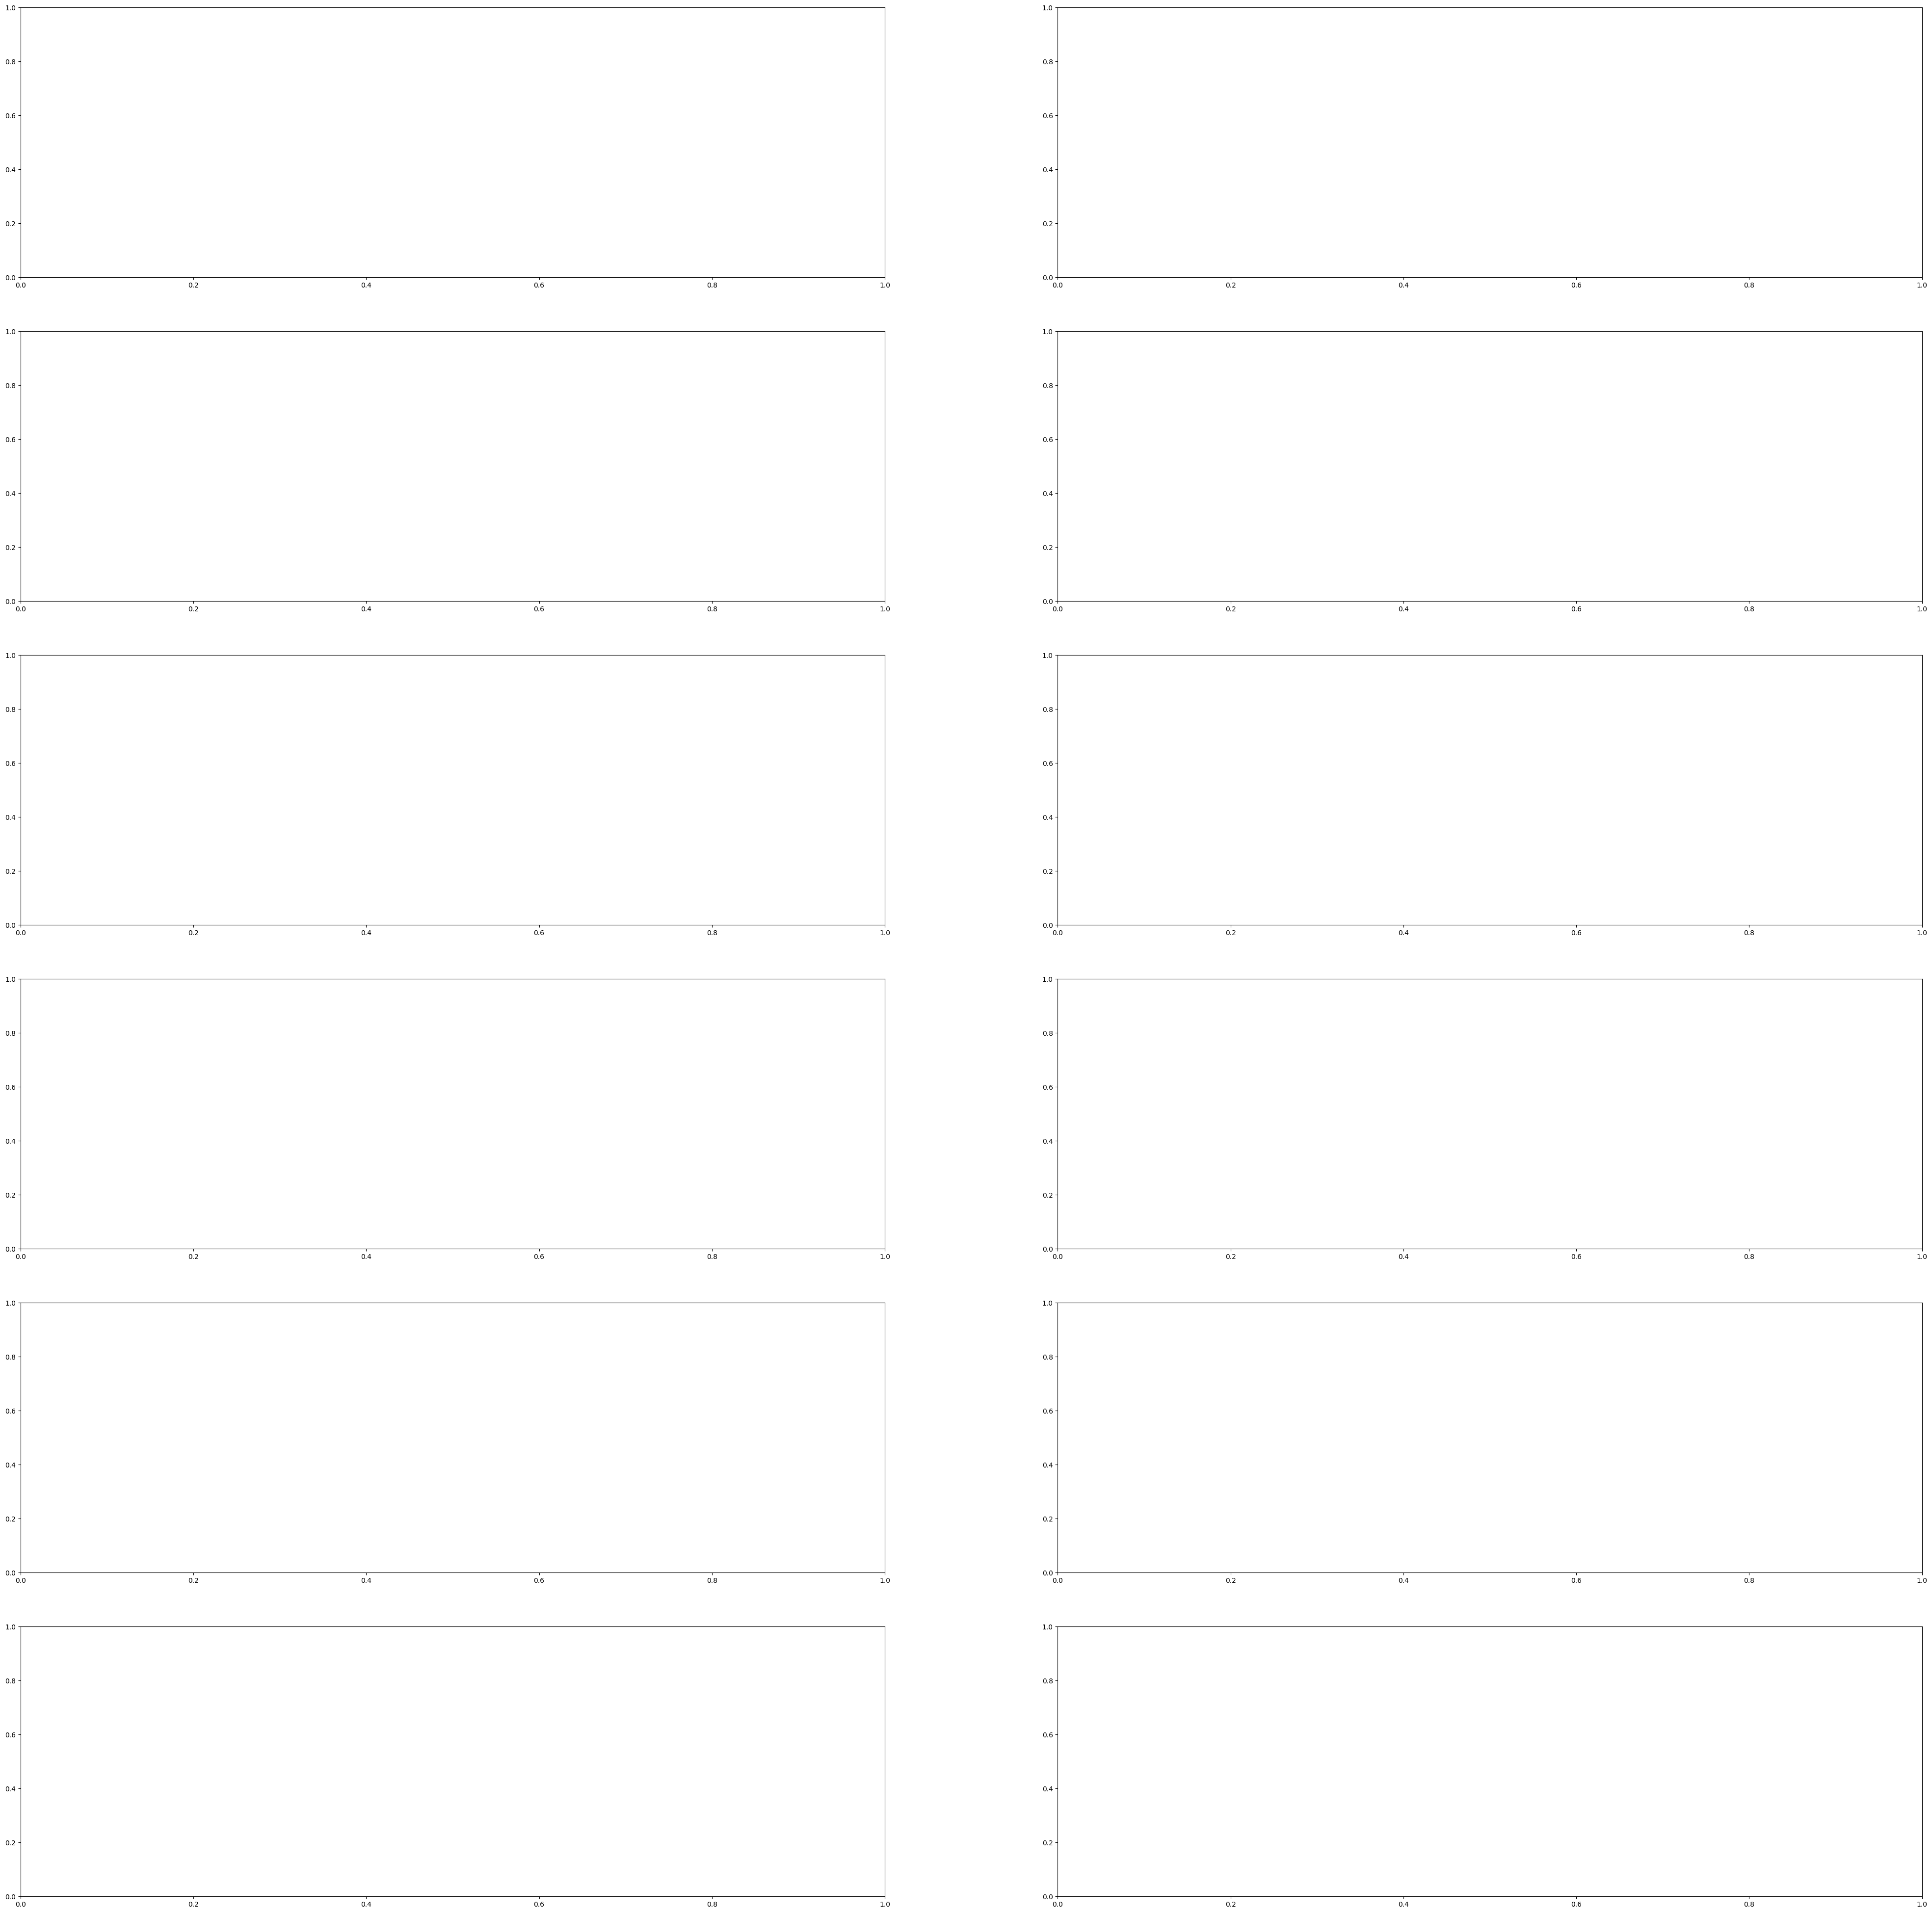

In [17]:

def visualize_depth_map(samples, test=False, model=None):
    input, target = samples
    cmap = plt.cm.jet
    cmap.set_bad(color="black")

    if test:
        pred = model.predict(input)
        fig, ax = plt.subplots(6, 3, figsize=(50, 50))
        for i in range(6):
            ax[i, 0].imshow((input[i].squeeze()))
            ax[i, 1].imshow((target[i].squeeze()), cmap=cmap)
            ax[i, 2].imshow((pred[i].squeeze()), cmap=cmap)

    else:
        fig, ax = plt.subplots(6, 2, figsize=(50, 50))
        for i in range(6):
            ax[i, 0].imshow((input[i].squeeze()))
            ax[i, 1].imshow((target[i].squeeze()), cmap=cmap)


visualize_samples = next(
    iter(DataGenerator(data=df, batch_size=6, dim=(HEIGHT, WIDTH)))
)
visualize_depth_map(visualize_samples, test=False, model=None)

## Трехмерная визуализация облака точек

In [15]:
depth_vis = np.flipud(visualize_samples[1][1].squeeze())  # target
img_vis = np.flipud(visualize_samples[0][1].squeeze())  # input

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection="3d")

STEP = 3
for x in range(0, img_vis.shape[0], STEP):
    for y in range(0, img_vis.shape[1], STEP):
        ax.scatter(
            [depth_vis[x, y]] * 3,
            [y] * 3,
            [x] * 3,
            c=tuple(img_vis[x, y, :3] / 255),
            s=3,
        )
    ax.view_init(45, 135)

IndexError: index 1 is out of bounds for axis 0 with size 0

## Building the model

1. The basic model is from U-Net.
2. Addditive skip-connections are implemented in the downscaling block.

In [ ]:

class DownscaleBlock(layers.Layer):
    def __init__(
        self, filters, kernel_size=(3, 3), padding="same", strides=1, **kwargs
    ):
        super().__init__(**kwargs)
        self.convA = layers.Conv2D(filters, kernel_size, strides, padding)
        self.convB = layers.Conv2D(filters, kernel_size, strides, padding)
        self.reluA = layers.LeakyReLU(negative_slope=0.2)
        self.reluB = layers.LeakyReLU(negative_slope=0.2)
        self.bn2a = layers.BatchNormalization()
        self.bn2b = layers.BatchNormalization()

        self.pool = layers.MaxPool2D((2, 2), (2, 2))

    def call(self, input_tensor):
        d = self.convA(input_tensor)
        x = self.bn2a(d)
        x = self.reluA(x)

        x = self.convB(x)
        x = self.bn2b(x)
        x = self.reluB(x)

        x += d
        p = self.pool(x)
        return x, p


class UpscaleBlock(layers.Layer):
    def __init__(
        self, filters, kernel_size=(3, 3), padding="same", strides=1, **kwargs
    ):
        super().__init__(**kwargs)
        self.us = layers.UpSampling2D((2, 2))
        self.convA = layers.Conv2D(filters, kernel_size, strides, padding)
        self.convB = layers.Conv2D(filters, kernel_size, strides, padding)
        self.reluA = layers.LeakyReLU(negative_slope=0.2)
        self.reluB = layers.LeakyReLU(negative_slope=0.2)
        self.bn2a = layers.BatchNormalization()
        self.bn2b = layers.BatchNormalization()
        self.conc = layers.Concatenate()

    def call(self, x, skip):
        x = self.us(x)
        concat = self.conc([x, skip])
        x = self.convA(concat)
        x = self.bn2a(x)
        x = self.reluA(x)

        x = self.convB(x)
        x = self.bn2b(x)
        x = self.reluB(x)

        return x


class BottleNeckBlock(layers.Layer):
    def __init__(
        self, filters, kernel_size=(3, 3), padding="same", strides=1, **kwargs
    ):
        super().__init__(**kwargs)
        self.convA = layers.Conv2D(filters, kernel_size, strides, padding)
        self.convB = layers.Conv2D(filters, kernel_size, strides, padding)
        self.reluA = layers.LeakyReLU(negative_slope=0.2)
        self.reluB = layers.LeakyReLU(negative_slope=0.2)

    def call(self, x):
        x = self.convA(x)
        x = self.reluA(x)
        x = self.convB(x)
        x = self.reluB(x)
        return x


## Определение потерь

В нашем режиме мы оптимизируем 3 вида потерь.
1. Индекс структурного сходства (SSIM).
2. Потери L1, или в нашем случае попиксельные потери глубины.
3. Потери гладкости глубины.

Из этих трёх функций потерь SSIM больше всего способствует повышению производительности модели.

In [ ]:

def image_gradients(image):
    if len(ops.shape(image)) != 4:
        raise ValueError(
            "image_gradients expects a 4D tensor "
            "[batch_size, h, w, d], not {}.".format(ops.shape(image))
        )

    image_shape = ops.shape(image)
    batch_size, height, width, depth = ops.unstack(image_shape)

    dy = image[:, 1:, :, :] - image[:, :-1, :, :]
    dx = image[:, :, 1:, :] - image[:, :, :-1, :]

    # Return tensors with same size as original image by concatenating
    # zeros. Place the gradient [I(x+1,y) - I(x,y)] on the base pixel (x, y).
    shape = ops.stack([batch_size, 1, width, depth])
    dy = ops.concatenate([dy, ops.zeros(shape, dtype=image.dtype)], axis=1)
    dy = ops.reshape(dy, image_shape)

    shape = ops.stack([batch_size, height, 1, depth])
    dx = ops.concatenate([dx, ops.zeros(shape, dtype=image.dtype)], axis=2)
    dx = ops.reshape(dx, image_shape)

    return dy, dx


class DepthEstimationModel(keras.Model):
    def __init__(self):
        super().__init__()
        self.ssim_loss_weight = 0.85
        self.l1_loss_weight = 0.1
        self.edge_loss_weight = 0.9
        self.loss_metric = keras.metrics.Mean(name="loss")
        f = [16, 32, 64, 128, 256]
        self.downscale_blocks = [
            DownscaleBlock(f[0]),
            DownscaleBlock(f[1]),
            DownscaleBlock(f[2]),
            DownscaleBlock(f[3]),
        ]
        self.bottle_neck_block = BottleNeckBlock(f[4])
        self.upscale_blocks = [
            UpscaleBlock(f[3]),
            UpscaleBlock(f[2]),
            UpscaleBlock(f[1]),
            UpscaleBlock(f[0]),
        ]
        self.conv_layer = layers.Conv2D(1, (1, 1), padding="same", activation="tanh")

    def calculate_loss(self, target, pred):
        # Edges
        dy_true, dx_true = image_gradients(target)
        dy_pred, dx_pred = image_gradients(pred)
        weights_x = ops.cast(ops.exp(ops.mean(ops.abs(dx_true))), "float32")
        weights_y = ops.cast(ops.exp(ops.mean(ops.abs(dy_true))), "float32")

        # Depth smoothness
        smoothness_x = dx_pred * weights_x
        smoothness_y = dy_pred * weights_y

        depth_smoothness_loss = ops.mean(abs(smoothness_x)) + ops.mean(
            abs(smoothness_y)
        )

        # Structural similarity (SSIM) index
        ssim_loss = ops.mean(
            1
            - tf.image.ssim(
                target, pred, max_val=WIDTH, filter_size=7, k1=0.01**2, k2=0.03**2
            )
        )
        # Point-wise depth
        l1_loss = ops.mean(ops.abs(target - pred))

        loss = (
            (self.ssim_loss_weight * ssim_loss)
            + (self.l1_loss_weight * l1_loss)
            + (self.edge_loss_weight * depth_smoothness_loss)
        )

        return loss

    @property
    def metrics(self):
        return [self.loss_metric]

    def train_step(self, batch_data):
        input, target = batch_data
        with tf.GradientTape() as tape:
            pred = self(input, training=True)
            loss = self.calculate_loss(target, pred)

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        self.loss_metric.update_state(loss)
        return {
            "loss": self.loss_metric.result(),
        }

    def test_step(self, batch_data):
        input, target = batch_data

        pred = self(input, training=False)
        loss = self.calculate_loss(target, pred)

        self.loss_metric.update_state(loss)
        return {
            "loss": self.loss_metric.result(),
        }

    def call(self, x):
        c1, p1 = self.downscale_blocks[0](x)
        c2, p2 = self.downscale_blocks[1](p1)
        c3, p3 = self.downscale_blocks[2](p2)
        c4, p4 = self.downscale_blocks[3](p3)

        bn = self.bottle_neck_block(p4)

        u1 = self.upscale_blocks[0](bn, c4)
        u2 = self.upscale_blocks[1](u1, c3)
        u3 = self.upscale_blocks[2](u2, c2)
        u4 = self.upscale_blocks[3](u3, c1)

        return self.conv_layer(u4)


## Модельное обучение

In [ ]:
optimizer = keras.optimizers.SGD(
    learning_rate=LR,
    nesterov=False,
)
model = DepthEstimationModel()
# Compile the model
model.compile(optimizer)

train_loader = DataGenerator(
    data=df[:260].reset_index(drop="true"), batch_size=BATCH_SIZE, dim=(HEIGHT, WIDTH)
)
validation_loader = DataGenerator(
    data=df[260:].reset_index(drop="true"), batch_size=BATCH_SIZE, dim=(HEIGHT, WIDTH)
)
model.fit(
    train_loader,
    epochs=EPOCHS,
    validation_data=validation_loader,
)

## Визуализация результатов работы модели

Мы визуализируем результаты работы модели на проверочном наборе данных.
 Первое изображение — это RGB-изображение, второе — эталонное изображение карты глубины,
а третье — прогнозируемое изображение карты глубины.

In [ ]:
test_loader = next(
    iter(
        DataGenerator(
            data=df[265:].reset_index(drop="true"), batch_size=6, dim=(HEIGHT, WIDTH)
        )
    )
)
visualize_depth_map(test_loader, test=True, model=model)

test_loader = next(
    iter(
        DataGenerator(
            data=df[300:].reset_index(drop="true"), batch_size=6, dim=(HEIGHT, WIDTH)
        )
    )
)
visualize_depth_map(test_loader, test=True, model=model)

## Возможные улучшения

1. Вы можете улучшить эту модель, заменив кодирующую часть U-Net на предварительно обученную DenseNet или ResNet.
2. Функции потерь играют важную роль в решении этой задачи.
Настройка функций потерь может значительно улучшить модель.

## Ссылки

В следующих статьях более подробно рассматриваются возможные подходы к оценке глубины.
1. [Прогнозирование глубины без датчиков: использование структуры для обучения без учителя на основе монокулярных видеозаписей](https://arxiv.org/abs/1811.06152v1)
2. [Изучение монокулярной оценки глубины с помощью самообучения](https://openaccess.thecvf.com/content_ICCV_2019/papers/Godard_Digging_Into_Self-Supervised_Monocular_Depth_Estimation_ICCV_2019_paper.pdf)
3. [Более глубокое прогнозирование глубины с помощью полностью свёрточных остаточных сетей](https://arxiv.org/abs/1606.00373v2)

Вы также можете найти полезные реализации в статьях с кодом для оценки глубины.

Вы можете использовать обученную модель, размещенную на [Hugging Face Hub](https://huggingface.co/spaces/keras-io/Monocular-Depth-Estimation),
и попробовать демоверсию на [Hugging Face Spaces](https://huggingface.co/keras-io/monocular-depth-estimation).